# Chapter 23: NeqSim Production Optimization Framework

This notebook demonstrates the NeqSim production optimization framework for finding the maximum
feasible production rate through a process train. The optimizer uses a binary feasibility search
to identify the bottleneck equipment and optimal operating point.

**Key Concepts:**
- Building a process model with equipment constraints
- Configuring and running ProductionOptimizer
- Identifying bottlenecks and utilization levels
- Production feasibility curves

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch25_optimization_framework.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 23.1 Build the Process Model

We build a simple gas processing train: feed stream → HP separator → compressor → export cooler.
Each equipment item has physical constraints that limit throughput.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# --- Fluid definition: lean natural gas ---
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 65.0)
fluid.addComponent("nitrogen", 0.02)
fluid.addComponent("CO2", 0.03)
fluid.addComponent("methane", 0.80)
fluid.addComponent("ethane", 0.08)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-butane", 0.02)
fluid.addComponent("n-hexane", 0.01)
fluid.setMixingRule("classic")

# --- Equipment ---
feed = jneqsim.process.equipment.stream.Stream("Feed Gas", fluid)
feed.setFlowRate(50000.0, "kg/hr")
feed.setTemperature(25.0, "C")
feed.setPressure(65.0, "bara")

separator = jneqsim.process.equipment.separator.Separator("HP Separator", feed)

compressor = jneqsim.process.equipment.compressor.Compressor("Export Compressor", separator.getGasOutStream())
compressor.setOutletPressure(150.0)
# The 5000 kW nameplate is enforced below through the optimizer's total-power limit.
compressor.setMaximumSpeed(12000.0)  # RPM; a speed limit is distinct from a power limit.

cooler = jneqsim.process.equipment.heatexchanger.Cooler("Export Cooler", compressor.getOutletStream())
cooler.setOutTemperature(273.15 + 35.0)

# --- Assemble process ---
process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.add(compressor)
process.add(cooler)
process.run()

print(f"Feed rate: {feed.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Compressor power: {compressor.getPower('kW'):.1f} kW")
print(f"Compressor outlet T: {compressor.getOutletStream().getTemperature('C'):.1f} °C")
print(f"Export temperature: {cooler.getOutletStream().getTemperature('C'):.1f} °C")

Feed rate: 50000 kg/hr
Compressor power: 1285.7 kW
Compressor outlet T: 86.8 °C
Export temperature: 35.0 °C


## 23.2 Configure and Run the Production Optimizer

The `ProductionOptimizer` uses a binary feasibility search to find the maximum feed rate
at which all equipment constraints are satisfied. The optimizer evaluates equipment utilization
at each trial rate and converges on the optimal operating point.

In [3]:
# Current FlowRateOptimizer API; all candidates run the complete process.
FlowRateOptimizer = jneqsim.process.util.optimizer.FlowRateOptimizer
optimizer = FlowRateOptimizer(process, "Feed Gas", "Export Cooler")
optimizer.setAutoConfigureProcessCompressors(False)  # fixed-pressure design calculation, no synthetic map
optimizer.setCheckCapacityConstraints(False)  # equipment curves are unspecified in this screening case
optimizer.setMinFlowRate(20000.0)
optimizer.setMaxFlowRate(200000.0)
optimizer.setMaxTotalPowerLimit(4750.0)  # kW = 95% of the assumed 5000 kW nameplate
optimizer.setMaxEquipmentUtilizationLimit(1e6)  # only the declared total-power constraint is qualified here
result = optimizer.findMaximumFeasibleFlowRate(65.0, "bara", 1e6)
assert result is not None and result.isFeasible(), "No feasible operating point was found"
opt_rate = float(result.getFlowRate())
opt_value = float(result.getTotalPower())
feed.setFlowRate(opt_rate, "kg/hr")
process.run()
assert compressor.getPower("kW") <= 4750.0 + 1.0
assert abs(cooler.getOutletStream().getPressure("bara") - 150.0) < 1e-6
optimization_result = {"optimal_rate_kg_hr": opt_rate, "power_kW": opt_value,
                       "power_limit_kW": 4750.0, "feasible": bool(result.isFeasible()),
                       "scope": "power-limited fixed-pressure screening; map and vessel constraints not supplied"}
print(f"Maximum feasible sampled-resolution rate: {opt_rate:.1f} kg/hr")
print(f"Compressor power: {opt_value:.2f} kW; screening limit: 4750 kW")


Maximum feasible sampled-resolution rate: 184707.0 kg/hr
Compressor power: 4749.61 kW; screening limit: 4750 kW


## 23.3 Equipment Utilization Sweep

We sweep the feed rate from 20,000 to 120,000 kg/hr and track the utilization of each
equipment item. The equipment that reaches 100% utilization first is the bottleneck.

In [4]:
# --- Sweep feed rate and record utilization ---
rates = np.linspace(20000, 240000, 25)
comp_power_frac = []
comp_power_kw = []

for rate in rates:
    feed.setFlowRate(float(rate), "kg/hr")
    process.run()
    power = compressor.getPower("kW")
    comp_power_kw.append(power)
    comp_power_frac.append(power / 5000.0)  # fraction of max power

comp_power_frac = np.array(comp_power_frac)
comp_power_kw = np.array(comp_power_kw)

# Reset to optimal
feed.setFlowRate(50000.0, "kg/hr")
process.run()

print(f"Rate sweep complete: {len(rates)} points evaluated")
print(f"Compressor power range: {comp_power_kw.min():.0f} - {comp_power_kw.max():.0f} kW")

Rate sweep complete: 25 points evaluated
Compressor power range: 514 - 6171 kW


Figure saved: ../figures/ch25_utilization_vs_rate.png


ch25_optimization_framework.ipynb:cell8:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


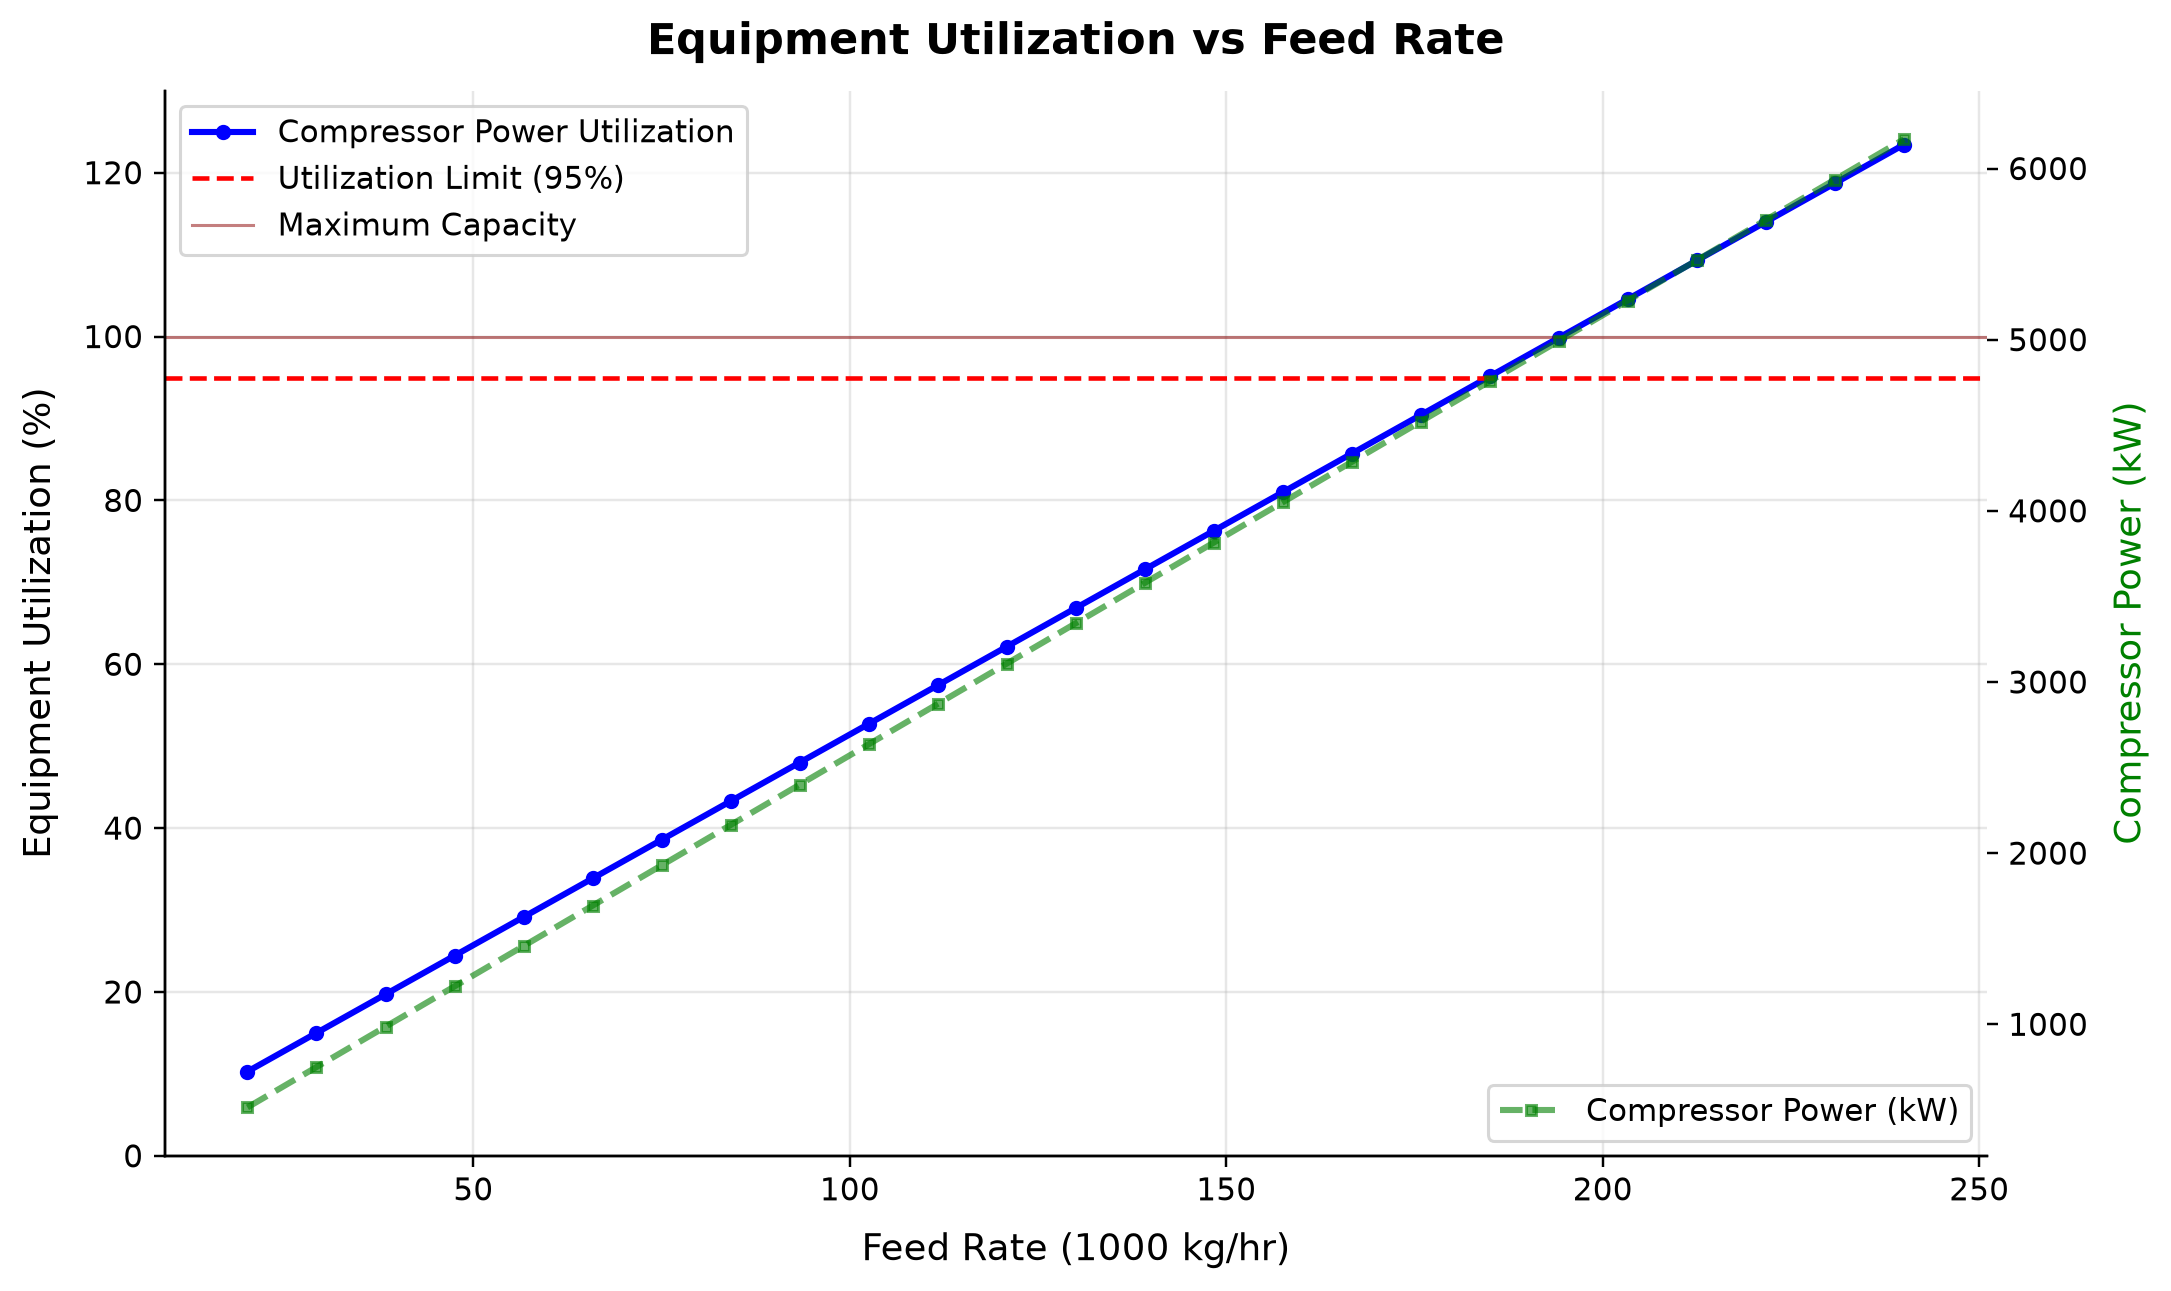

In [5]:
# --- Plot: Equipment utilization vs feed rate ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(rates / 1000, comp_power_frac * 100, 'b-o', markersize=4, label='Compressor Power Utilization')
ax1.axhline(y=95, color='r', linestyle='--', linewidth=1.5, label='Utilization Limit (95%)')
ax1.axhline(y=100, color='darkred', linestyle='-', linewidth=1, alpha=0.5, label='Maximum Capacity')

ax1.set_xlabel('Feed Rate (1000 kg/hr)', fontsize=12)
ax1.set_ylabel('Equipment Utilization (%)', fontsize=12)
ax1.set_title('Equipment Utilization vs Feed Rate', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 130)

# Secondary axis: compressor power
ax2 = ax1.twinx()
ax2.plot(rates / 1000, comp_power_kw, 'g--s', markersize=3, alpha=0.6, label='Compressor Power (kW)')
ax2.set_ylabel('Compressor Power (kW)', fontsize=12, color='g')
ax2.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch25_utilization_vs_rate.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch25_utilization_vs_rate.png")

**Executed-figure discussion.** Compressor Power Utilization: equipment utilization spans 10.29–123.4 % across the plotted cases. Compressor Power (kW): compressor power spans 514.3–6171 kW across the plotted cases.

At fixed composition and pressure ratio, compressor shaft power scales approximately with mass rate. The declared power allowance controls this screening case; no vendor surge or stonewall map is supplied. Apply verified vessel and compressor-map limits before promoting the power-limited rate to an operating target.


## 23.4 Production Feasibility Curve

The feasibility curve shows whether each operating point is feasible (all constraints satisfied)
or infeasible. The transition boundary is the maximum production rate.

Figure saved: ../figures/ch25_feasibility_curve.png


ch25_optimization_framework.ipynb:cell10:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


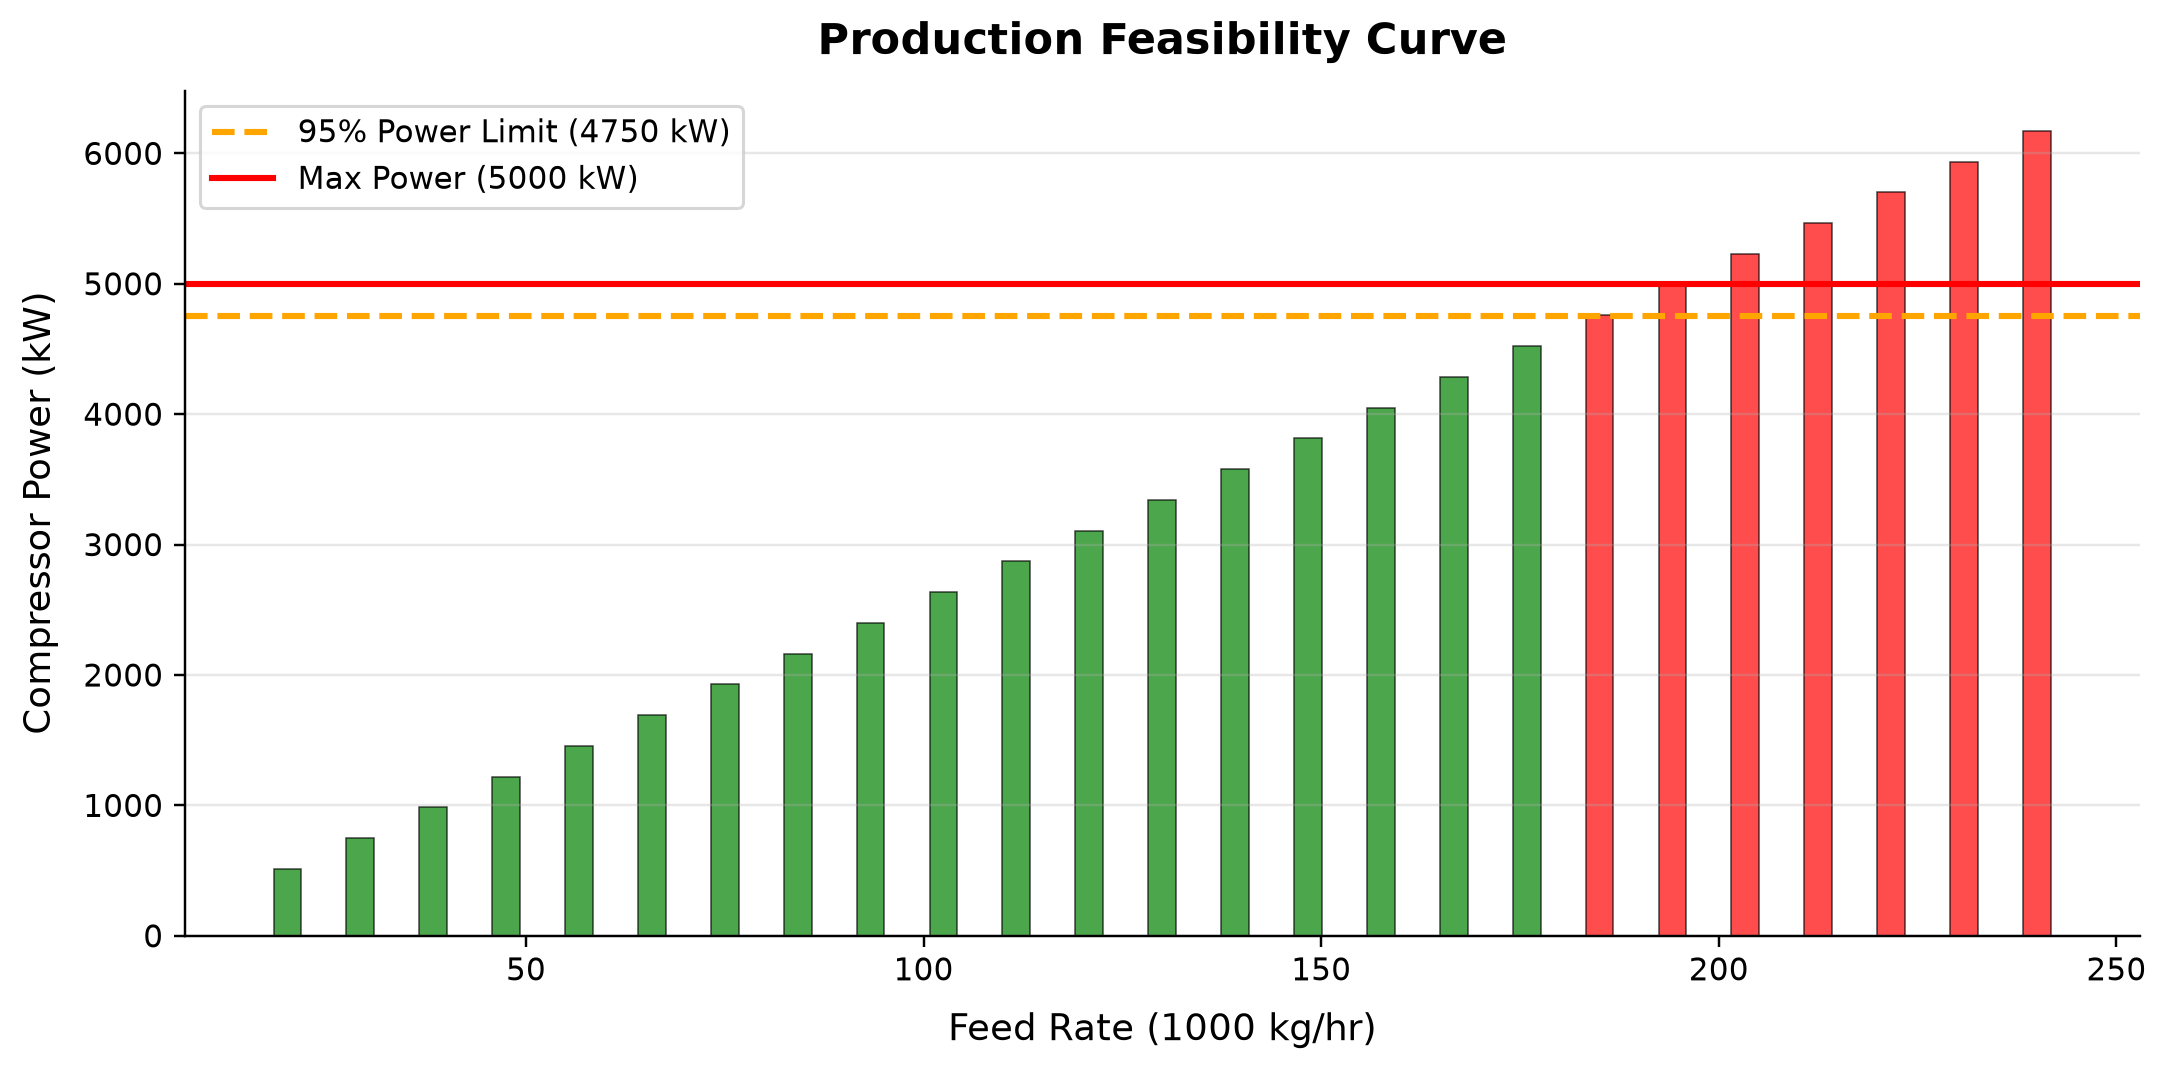

In [6]:
# --- Production feasibility curve ---
feasible = comp_power_frac <= 0.95  # feasible if utilization <= 95%

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if f else 'red' for f in feasible]
ax.bar(rates / 1000, comp_power_kw, width=3.5, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(y=5000 * 0.95, color='orange', linestyle='--', linewidth=2, label='95% Power Limit (4750 kW)')
ax.axhline(y=5000, color='red', linestyle='-', linewidth=2, label='Max Power (5000 kW)')

ax.set_xlabel('Feed Rate (1000 kg/hr)', fontsize=12)
ax.set_ylabel('Compressor Power (kW)', fontsize=12)
ax.set_title('Production Feasibility Curve', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add feasibility annotation

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch25_feasibility_curve.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch25_feasibility_curve.png")

**Executed-figure discussion.** The sampled compression powers span 514.3–6171.4 kW. The current FlowRateOptimizer returns 184.707 t/hr under the separately declared 4750 kW screening limit.

Every bar comes from a NeqSim process run at the corresponding feed rate and is judged against the declared power threshold. The highest sampled feasible bar can differ from the optimizer result because the bar chart uses a coarse rate grid. Use the independently rerun optimizer point for the final numerical result.


## 23.5 Summary

The NeqSim production optimization framework provides:

1. **Automated bottleneck identification** — the optimizer identifies which equipment limits production
2. **Binary feasibility search** — efficient convergence to the optimal rate within tolerance
3. **Equipment utilization tracking** — quantitative utilization metrics for each equipment item
4. **Production feasibility curves** — visual identification of operating boundaries

The compressor power constraint typically dominates in gas processing trains, but the framework
handles any combination of equipment constraints (separator capacity, valve Cv, heat exchanger duty, etc.).

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                      Figure  Panel                       Series             Output / unit  Minimum  Maximum  Finite points  Missing points
ch25_utilization_vs_rate.png      1 Compressor Power Utilization Equipment Utilization (%)  10.2857  123.429             25               0
ch25_utilization_vs_rate.png      1      Utilization Limit (95%) Equipment Utilization (%)       95       95              2               0
ch25_utilization_vs_rate.png      1             Maximum Capacity Equipment Utilization (%)      100      100              2               0
ch25_utilization_vs_rate.png      2        Compressor Power (kW)     Compressor Power (kW)  514.286  6171.43             25               0
  ch25_feasibility_curve.png      1    95% Power Limit (4750 kW)     Compressor Power (kW)     4750     4750              2               0
  ch25_feasibility_curve.png      1          Max Power (5000 kW)     Compressor Power (kW)     5000     5000              2               0
  ch25_feasibility_c